<a href="https://colab.research.google.com/github/melike0019/GTZAN-Audio-Classification/blob/buse/data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# Hücre 1 — Kaggle kurulumu
!pip install kaggle -q
import os
os.environ['KAGGLE_TOKEN'] = 'KGAT_f15c2072c59d064ecbd264e4bb419abb'
!mkdir -p ~/.kaggle
!echo '{"token":"KGAT_f15c2072c59d064ecbd264e4bb419abb"}' > ~/.kaggle/access_token
!chmod 600 ~/.kaggle/access_token
print("✓ Kaggle hazır")


✓ Kaggle hazır


In [6]:
# Hücre 2 — Drive'ı bağla
from google.colab import drive
drive.mount('/content/drive')
print("✓ Drive bağlandı")

Mounted at /content/drive
✓ Drive bağlandı


In [7]:

!kaggle datasets download -d andradaolteanu/gtzan-dataset-music-genre-classification \
    -p /content/drive/MyDrive/gtzan_project/Data
print("✓ İndirme tamamlandı")

Dataset URL: https://www.kaggle.com/datasets/andradaolteanu/gtzan-dataset-music-genre-classification
License(s): other
gtzan-dataset-music-genre-classification.zip: Skipping, found more recently modified local copy (use --force to force download)
✓ İndirme tamamlandı


In [8]:
import os
print(os.listdir("/content/drive/MyDrive/gtzan_project/Data"))

['gtzan-dataset-music-genre-classification.zip', '.gitkeep', 'Data']


In [9]:
# Hücre 4 — Zip'i Drive'da aç
!unzip -o -q /content/drive/MyDrive/gtzan_project/Data/gtzan-dataset-music-genre-classification.zip \
    -d /content/drive/MyDrive/gtzan_project/Data/
print("✓ Zip açıldı")

✓ Zip açıldı


In [10]:
# Hücre 5 — Kontrol et
import os
genres = os.listdir("/content/drive/MyDrive/gtzan_project/Data/Data/genres_original")
print(f"✓ {len(genres)} tür bulundu: {sorted(genres)}")

✓ 10 tür bulundu: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


In [11]:
import librosa
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = Path("/content/drive/MyDrive/gtzan_project/Data/Data/genres_original")
valid = []
broken = []

for genre_dir in sorted(DATA_DIR.iterdir()):
    if not genre_dir.is_dir():
        continue
    for fpath in sorted(genre_dir.glob("*.wav")):
        try:
            y, sr = librosa.load(fpath, duration=1.0)
            valid.append((fpath, genre_dir.name))
        except Exception as e:
            broken.append(fpath.name)
            print(f"BOZUK: {fpath.name} — {e}")

print(f"\n✓ Geçerli: {len(valid)} | Bozuk: {len(broken)}")

BOZUK: jazz.00054.wav — 

✓ Geçerli: 999 | Bozuk: 1


In [12]:
## Gün 2 — Mel Spectrogram
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt

print("✓ Hazır")


✓ Hazır


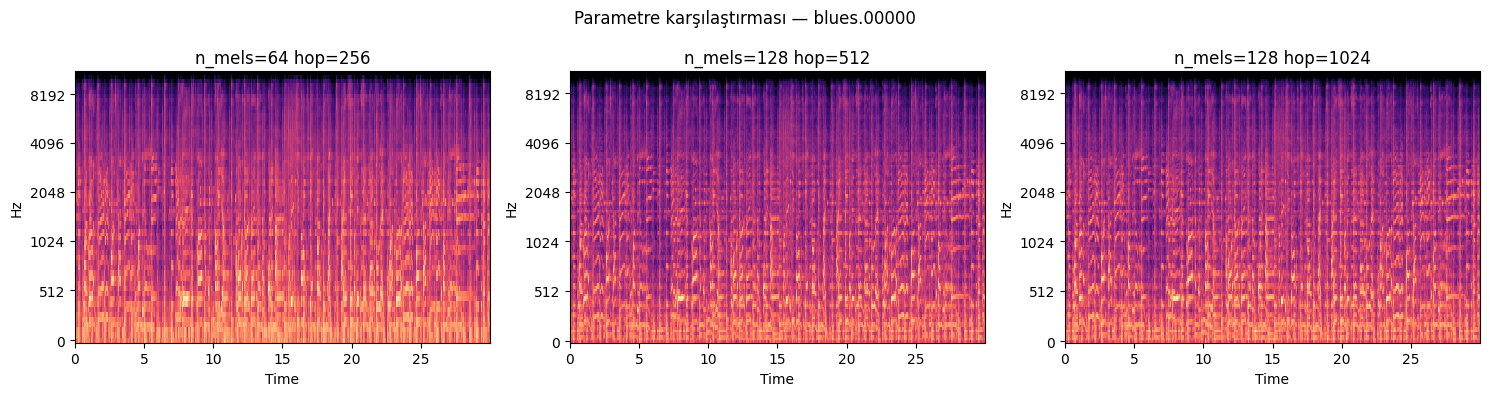

In [13]:
##3 farklı parametre karşılaştırması
test_file = DATA_DIR / "blues" / "blues.00000.wav"
y, sr = librosa.load(test_file, sr=22050, duration=30)

configs = [
    {"n_mels": 64,  "n_fft": 1024, "hop_length": 256},
    {"n_mels": 128, "n_fft": 2048, "hop_length": 512},   # ← önerilen
    {"n_mels": 128, "n_fft": 2048, "hop_length": 1024},
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, cfg in enumerate(configs):
    mel = librosa.feature.melspectrogram(y=y, sr=sr, **cfg)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    librosa.display.specshow(mel_db, sr=sr, ax=axes[i],
        hop_length=cfg["hop_length"], x_axis="time", y_axis="mel")
    axes[i].set_title(f"n_mels={cfg['n_mels']} hop={cfg['hop_length']}")
plt.suptitle("Parametre karşılaştırması — blues.00000")
plt.tight_layout()
plt.show()

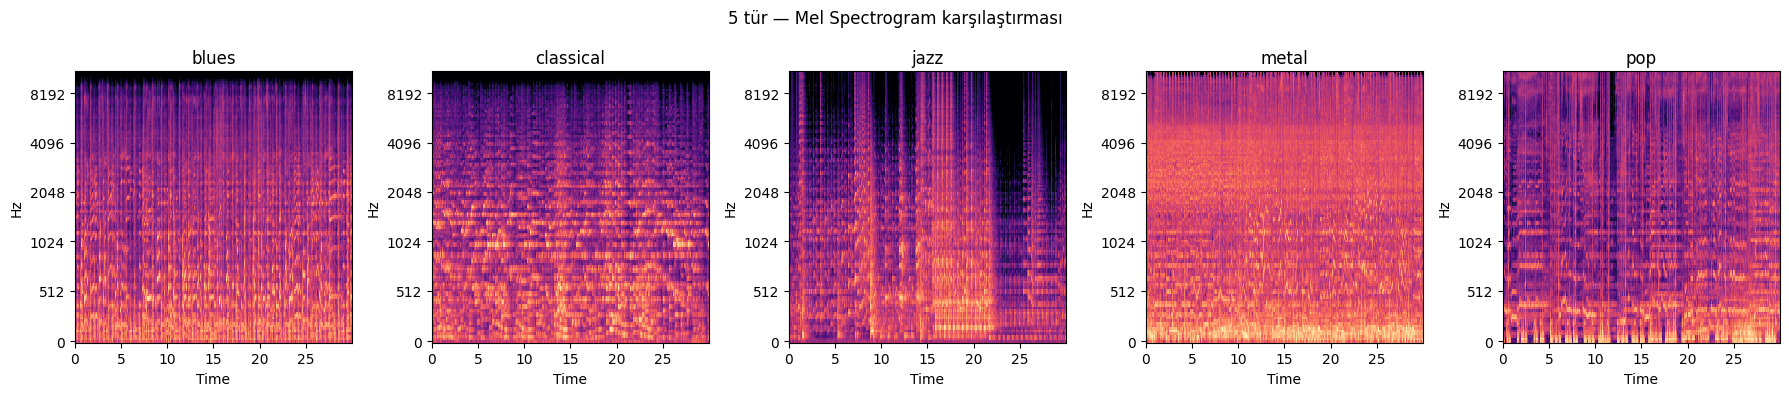

In [14]:
# Hücre 3 — 5 türü yan yana karşılaştır
genres_to_compare = ["blues", "classical", "jazz", "metal", "pop"]
SR, N_MELS, N_FFT, HOP = 22050, 128, 2048, 512

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for i, genre in enumerate(genres_to_compare):
    fpath = DATA_DIR / genre / f"{genre}.00000.wav"
    y, sr = librosa.load(fpath, sr=SR, duration=30)
    mel = librosa.feature.melspectrogram(
        y=y, sr=sr, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    librosa.display.specshow(mel_db, sr=sr, hop_length=HOP,
        x_axis="time", y_axis="mel", ax=axes[i], cmap="magma")
    axes[i].set_title(genre)
plt.suptitle("5 tür — Mel Spectrogram karşılaştırması")
plt.tight_layout()
plt.show()

In [15]:
import numpy as np
from pathlib import Path
from tqdm import tqdm

SR, N_MELS, N_FFT, HOP = 22050, 128, 2048, 512
DURATION = 30
SAVE_DIR = Path("/content/drive/MyDrive/gtzan_project/Processed_Data")
SAVE_DIR.mkdir(exist_ok=True)

GENRES = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
genre_to_idx = {g: i for i, g in enumerate(GENRES)}
print("Tür → indeks:", genre_to_idx)

X_list, y_list = [], []

for fpath, genre in tqdm(valid, desc="İşleniyor"):
    y_audio, sr = librosa.load(fpath, sr=SR, duration=DURATION, mono=True)
    target = SR * DURATION
    if len(y_audio) < target:
        y_audio = np.pad(y_audio, (0, target - len(y_audio)))
    mel = librosa.feature.melspectrogram(
        y=y_audio, sr=sr, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP)
    mel_db = librosa.power_to_db(mel, ref=np.max).astype(np.float32)
    X_list.append(mel_db)
    y_list.append(genre_to_idx[genre])

X = np.array(X_list)
y = np.array(y_list)
print(f"\n✓ X shape: {X.shape} | y shape: {y.shape}")
print(f"Hafıza: {X.nbytes / 1e6:.1f} MB")

Tür → indeks: {'blues': 0, 'classical': 1, 'country': 2, 'disco': 3, 'hiphop': 4, 'jazz': 5, 'metal': 6, 'pop': 7, 'reggae': 8, 'rock': 9}


İşleniyor: 100%|██████████| 999/999 [01:38<00:00, 10.15it/s]



✓ X shape: (999, 128, 1292) | y shape: (999,)
Hafıza: 660.8 MB


In [16]:
from sklearn.model_selection import train_test_split

# Train/Val/Test split
X_tv, X_test, y_tv, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.1765, random_state=42, stratify=y_tv)

print(f"Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")

Train: 699 | Val: 150 | Test: 150


In [17]:
# Normalizasyon (sadece train üzerinden)
X_mean = X_train.mean()
X_std  = X_train.std()

X_train_n = (X_train - X_mean) / (X_std + 1e-8)
X_val_n   = (X_val   - X_mean) / (X_std + 1e-8)
X_test_n  = (X_test  - X_mean) / (X_std + 1e-8)

print(f"Mean: {X_mean:.4f} | Std: {X_std:.4f}")
print("✓ Normalizasyon tamamlandı")

Mean: -42.7981 | Std: 15.5427
✓ Normalizasyon tamamlandı


In [18]:
# Drive'a kaydet
np.save(SAVE_DIR / "X_train.npy", X_train_n)
np.save(SAVE_DIR / "X_val.npy",   X_val_n)
np.save(SAVE_DIR / "X_test.npy",  X_test_n)
np.save(SAVE_DIR / "y_train.npy", y_train)
np.save(SAVE_DIR / "y_val.npy",   y_val)
np.save(SAVE_DIR / "y_test.npy",  y_test)
np.save(SAVE_DIR / "mean_std.npy", np.array([X_mean, X_std]))

print("✓ Tüm dosyalar Processed_Data'ya kaydedildi!")
for f in sorted(SAVE_DIR.glob("*.npy")):
    print(f"  {f.name}  ({f.stat().st_size / 1e6:.1f} MB)")

✓ Tüm dosyalar Processed_Data'ya kaydedildi!
  X_test.npy  (99.2 MB)
  X_train.npy  (462.4 MB)
  X_val.npy  (99.2 MB)
  mean_std.npy  (0.0 MB)
  y_test.npy  (0.0 MB)
  y_train.npy  (0.0 MB)
  y_val.npy  (0.0 MB)
